[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/takechanman1228/marketing-science-in-python/blob/main/notebooks/part3-causal-inference/sec3.5_meta_learners.ipynb)

# Estimating Heterogeneous Treatment Effects with Meta-Learners

Companion notebook for **§3.5 Meta Learners for Treatment Effects** of
*Marketing Science in Python*. The goal here is **measurement**: estimating
the **Conditional Average Treatment Effect (CATE)** with several meta-learners.
Turning those estimates into targeting decisions is the job of §3.6.

**Methods covered:**
- S-Learner, T-Learner, X-Learner (classic meta-learners)
- DR-Learner (Doubly Robust)
- Causal Forest DML

**Why a semi-synthetic example?** In real data we never observe an individual's
true treatment effect, so we cannot check whether a meta-learner recovered the
right *heterogeneous* pattern. Here we take the **real customer features** from
Kevin Hillstrom's MineThatData e-mail experiment, but **simulate** the potential
outcomes from a treatment effect `true_tau(x)` that we define. Because the truth
is known, we can score each learner on how well its estimated CATE matches it.
This is a teaching device, not a claim that we can beat a randomized experiment's
average effect.

**Data:** Kevin Hillstrom, *The MineThatData E-Mail Analytics And Data Mining
Challenge* (2008). We use the real randomized assignment for the binary
treatment (Men's e-mail vs. no e-mail) and the real customer covariates; only
the outcomes are simulated.

### Setup

Required packages: `econml`, `lightgbm`. They are pinned in this project's
`environment.yml` (conda env `marketing-science`) and
`notebooks/part3-causal-inference/requirements.txt`. The data and figure paths
are resolved through the `msbook` helper package (installed with
`pip install -e .` from the repo root). **Colab readers** can install the
modelling packages by uncommenting:

```python
!pip install -q econml lightgbm scikit-uplift
```

In [1]:
import importlib.metadata
import sys

print(f"Python: {sys.version}")
print(f"econml: {importlib.metadata.version('econml')}")
print(f"lightgbm: {importlib.metadata.version('lightgbm')}")
print(f"scikit-learn: {importlib.metadata.version('scikit-learn')}")

# --- Compatibility patch: econml 0.16 uses deprecated `force_all_finite` ---
# scikit-learn >=1.8 renamed check_array(force_all_finite=...) to
# check_array(ensure_all_finite=...). Patch until econml releases a fix.
import sklearn.utils.validation as _skval
_original_check_array = _skval.check_array

def _patched_check_array(*args, **kwargs):
    if 'force_all_finite' in kwargs:
        kwargs['ensure_all_finite'] = kwargs.pop('force_all_finite')
    return _original_check_array(*args, **kwargs)

_skval.check_array = _patched_check_array
import sklearn.utils
sklearn.utils.check_array = _patched_check_array
# --- End compatibility patch ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from scipy.special import expit

from lightgbm import LGBMRegressor, LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from econml.metalearners import SLearner, TLearner, XLearner
from econml.dr import DRLearner
from econml.dml import CausalForestDML

# Apply patch to all econml modules that imported check_array
for _mod_name in list(sys.modules.keys()):
    if _mod_name.startswith('econml') and hasattr(sys.modules[_mod_name], 'check_array'):
        sys.modules[_mod_name].check_array = _patched_check_array

# Suppress noisy logs and known-harmless warnings so the notebook output reads cleanly.
# We narrow the suppressions to specific categories / messages rather than blanket-ignoring,
# so genuine problems still surface.
import warnings
from sklearn.exceptions import DataConversionWarning
warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=DataConversionWarning)
warnings.filterwarnings(action='ignore', category=UserWarning,
                        message='X does not have valid feature names')

try:
    display
except NameError:
    display = print

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

Python: 3.12.8 | packaged by conda-forge | (main, Dec  5 2024, 08:43:59) [Clang 18.1.8 ]
econml: 0.16.0
lightgbm: 4.6.0
scikit-learn: 1.6.1


In [2]:
# Colab bootstrap: make the `msbook` helper package importable.
# Local / conda users already have it via `pip install -e .` from the repo root,
# so this is a no-op for them. On Colab it clones the book repo and installs
# msbook in editable mode. (A plain `pip install git+...` is not enough: msbook
# resolves paths by walking up to the repo root marker, so it needs the repo
# tree present, which the clone provides.)
try:
    import msbook  # noqa: F401
except ModuleNotFoundError:
    import subprocess
    _REPO = "https://github.com/takechanman1228/marketing-science-in-python.git"
    subprocess.run(["git", "clone", "-q", _REPO], check=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e",
                    "marketing-science-in-python"], check=True)
    import msbook  # noqa: F401

# Resolved by msbook so figures land in images/part3/sec3.5/ from any cwd.
from msbook.paths import chapter_images

_FIG_DIR = chapter_images(part="3", chapter="sec3.5")


def savefig(fig, name, **kw):
    kw.setdefault("dpi", 150)
    kw.setdefault("bbox_inches", "tight")
    fig.savefig(_FIG_DIR / name, **kw)

## 1. The MineThatData E-Mail Experiment

Kevin Hillstrom's [MineThatData challenge](https://blog.minethatdata.com/2008/03/minethatdata-e-mail-analytics-and-data.html)
is a 64,000-customer e-mail marketing experiment. Customers were randomized
into three arms — a **Men's** merchandise e-mail, a **Women's** merchandise
e-mail, and a **no-e-mail** control — then observed for two weeks.

| Column | Meaning |
|--------|---------|
| `recency` | months since last purchase (1–12) |
| `history` | dollars spent in the past year |
| `mens` / `womens` | bought men's / women's merchandise in the past year |
| `zip_code` | Urban / Suburban / Rural |
| `newbie` | new customer in the past year |
| `channel` | Phone / Web / Multichannel |
| `segment` | randomized arm (Mens / Womens / No E-Mail) |
| `visit`, `conversion`, `spend` | observed outcomes |

We keep the binary contrast **Men's e-mail vs. no e-mail** (dropping the
Women's arm) and use the real randomized assignment as our treatment.

In [3]:
from msbook.data import load_minethatdata

df = load_minethatdata()
print(f"Full dataset: {len(df):,} customers across {df['segment'].nunique()} arms")

# Keep the binary contrast: Men's e-mail (treatment) vs. No e-mail (control).
df = df[df['segment'].isin(['Mens E-Mail', 'No E-Mail'])].copy()
df['treatment'] = (df['segment'] == 'Mens E-Mail').astype(int)

print(f"After filtering to Men's e-mail vs. control: {len(df):,} customers")
print(f"Treatment rate (randomized): {df['treatment'].mean():.1%}")

Full dataset: 64,000 customers across 3 arms
After filtering to Men's e-mail vs. control: 42,613 customers
Treatment rate (randomized): 50.0%


## 2. Customer Features

We use a small, readable feature set: `recency`, `history`, `mens`, `newbie`,
plus one-hot encodings of `channel` and `zip_code`. We deliberately use
`history` (the dollar amount) and **not** `history_segment` (its bucketed
version) as a model feature — the two are redundant. (`history_segment` is not
used below at all; the segment plot buckets `history` into quartiles directly.)

In [4]:
feature_cols = ['recency', 'history', 'mens', 'newbie']
X = pd.get_dummies(
    df[feature_cols + ['channel', 'zip_code']],
    columns=['channel', 'zip_code'],
    drop_first=True,
).astype(float)

T = df['treatment'].to_numpy().astype(int)

print(f"Feature matrix: {X.shape[0]:,} rows x {X.shape[1]} columns")
print(f"Columns: {list(X.columns)}")
X.head()

Feature matrix: 42,613 rows x 8 columns
Columns: ['recency', 'history', 'mens', 'newbie', 'channel_Phone', 'channel_Web', 'zip_code_Surburban', 'zip_code_Urban']


,recency,history,mens,newbie,channel_Phone,channel_Web,zip_code_Surburban,zip_code_Urban
1,6.0,329.08,1.0,1.0,0.0,1.0,0.0,0.0
3,9.0,675.83,1.0,1.0,0.0,1.0,0.0,0.0
8,9.0,675.07,1.0,1.0,1.0,0.0,0.0,0.0
13,2.0,101.64,0.0,0.0,0.0,1.0,0.0,1.0
14,4.0,241.42,0.0,1.0,0.0,0.0,0.0,0.0


## 3. Semi-Synthetic Potential Outcomes

This is the heart of the example. We build, on the probability scale:

- a **baseline** purchase probability `p0` (what a customer does *without* the
  e-mail), driven by recency and spend history;
- a **true treatment effect** `true_tau(x)`, built from marketing-plausible
  patterns;
- the **treated** probability `p1 = clip(p0 + true_tau, 0, 1)`.

`true_tau(x)` is **larger** for men's-merchandise buyers, recently active
customers, and multichannel shoppers, with an added sweet spot in the middle of
the purchase-history range. It is **smaller** for very inactive customers, who
are hard to move. We then draw both potential outcomes and reveal only the one
matching each customer's actual arm.

In [5]:
# Standardized drivers
rec = df['recency'].to_numpy(dtype=float)
loghist = np.log(df['history'].to_numpy(dtype=float))
loghist_z = (loghist - loghist.mean()) / loghist.std()
mens = df['mens'].to_numpy(dtype=float)
newbie = df['newbie'].to_numpy(dtype=float)
multichannel = (df['channel'] == 'Multichannel').to_numpy(dtype=float)
urban = (df['zip_code'] == 'Urban').to_numpy(dtype=float)

# --- Baseline probability p0: what the customer would do with no e-mail ---
logit0 = (-2.2
          - 0.45 * (rec - rec.mean()) / rec.std()   # recent buyers convert more
          + 0.35 * loghist_z                          # bigger spenders convert more
          + 0.15 * mens
          - 0.25 * newbie
          + 0.10 * urban)
p0 = expit(logit0)

# --- True treatment effect true_tau(x), on the probability scale ---
# recently active -> near 1 for recency<=2, fading toward 0 by recency~8
recent_factor = expit(-(rec - 4.0) / 1.5)
# moderate-history bump: inverted-U, peaks at median log-history, low at the tails
hist_moderate = np.exp(-0.5 * (loghist_z / 1.0) ** 2)

true_tau = (0.005
            + 0.090 * mens            # men's e-mail moves men's buyers most
            + 0.050 * multichannel    # multichannel customers more responsive
            + 0.060 * recent_factor   # recently active respond more
            + 0.045 * hist_moderate)  # moderate-history sweet spot

# --- Treated probability and potential outcomes ---
p1 = np.clip(p0 + true_tau, 0.0, 1.0)
true_tau = p1 - p0                      # exact effect after clipping

y0 = rng.binomial(1, p0)
y1 = rng.binomial(1, p1)
y = np.where(T == 1, y1, y0).astype(int)   # observed outcome

df['p0'], df['p1'], df['true_tau'] = p0, p1, true_tau
df['y0'], df['y1'], df['y'] = y0, y1, y

print(f"Baseline rate  E[p0]      = {p0.mean():.3f}")
print(f"True ATE       E[true_tau] = {true_tau.mean():.4f}  ({true_tau.mean():.2%})")
print(f"True effect spread (SD)    = {true_tau.std():.4f}")
print(f"Observed conversion rate   = {y.mean():.3f}")

Baseline rate  E[p0]      = 0.114
True ATE       E[true_tau] = 0.1136  (11.36%)
True effect spread (SD)    = 0.0538
Observed conversion rate   = 0.169


## 4. The Counterfactual We Cannot Observe

For each customer, only the potential outcome matching their actual arm is
"observed"; the other is hidden. In real data the `Y(0)` / `Y(1)` we did not
see — and therefore `true_tau` — would simply be blank. Here we keep them
visible so we can grade the learners.

In [6]:
peek = df.sample(6, random_state=RANDOM_STATE).copy()
peek['Y(0)'] = np.where(peek['treatment'] == 1, '— (hidden)', peek['y0'].astype(str))
peek['Y(1)'] = np.where(peek['treatment'] == 1, peek['y1'].astype(str), '— (hidden)')
display(peek[['recency', 'history', 'mens', 'channel', 'treatment',
              'y', 'Y(0)', 'Y(1)', 'true_tau']].round(3))

,recency,history,mens,channel,treatment,y,Y(0),Y(1),true_tau
493,4,121.87,1,Web,0,0,0,— (hidden),0.169
21569,3,184.83,1,Phone,1,0,— (hidden),0,0.179
3531,2,400.48,0,Multichannel,0,0,0,— (hidden),0.131
50370,10,175.25,0,Web,1,0,— (hidden),0,0.050
38375,2,1640.42,1,Multichannel,1,1,— (hidden),1,0.195
57518,8,29.99,0,Web,1,0,— (hidden),0,0.023


## 5. Fit the Meta-Learners

We fit five estimators on a training split and estimate CATE on a held-out
split. The classic learners (S/T/X) use `LGBMRegressor` on the 0/1 outcome;
the DR-Learner and Causal Forest use `LGBMClassifier` nuisance models with
`discrete_outcome=True`. Because the treatment is randomized, all of them
should land near the true ATE — the interesting question is whether they
recover the *heterogeneity*.

In [7]:
X_train, X_eval, T_train, T_eval, y_train, y_eval, tau_train, tau_eval = train_test_split(
    X.to_numpy(), T, y, true_tau,
    test_size=0.30, stratify=T, random_state=RANDOM_STATE,
)
print(f"Train: {len(X_train):,} rows   Eval: {len(X_eval):,} rows")

lgbm_reg_params = dict(n_estimators=200, max_depth=5, learning_rate=0.05,
                       verbose=-1, random_state=RANDOM_STATE, n_jobs=-1)
lgbm_clf_params = dict(n_estimators=200, max_depth=5, learning_rate=0.05,
                       verbose=-1, random_state=RANDOM_STATE, n_jobs=-1)

estimators = {
    'S-Learner': SLearner(overall_model=LGBMRegressor(**lgbm_reg_params)),
    'T-Learner': TLearner(models=[LGBMRegressor(**lgbm_reg_params),
                                   LGBMRegressor(**lgbm_reg_params)]),
    'X-Learner': XLearner(
        models=[LGBMRegressor(**lgbm_reg_params), LGBMRegressor(**lgbm_reg_params)],
        propensity_model=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    ),
    'DR-Learner': DRLearner(
        model_regression=LGBMClassifier(**lgbm_clf_params),
        model_propensity=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        model_final=LGBMRegressor(**lgbm_reg_params),
        discrete_outcome=True, cv=3, mc_iters=3,
    ),
    'CausalForestDML': CausalForestDML(
        model_y=LGBMClassifier(**lgbm_clf_params),
        model_t=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        discrete_treatment=True, discrete_outcome=True,
        n_estimators=200, random_state=RANDOM_STATE, cv=3, mc_iters=3,
    ),
}

results = {}
y_train_f = y_train.astype(float)
for name, est in estimators.items():
    t0 = time.time()
    if name in ('S-Learner', 'T-Learner', 'X-Learner'):
        est.fit(y_train_f, T_train, X=X_train)
    else:
        est.fit(Y=y_train_f, T=T_train, X=X_train)
    cate = est.effect(X_eval).flatten()
    results[name] = {'cate': cate, 'time': time.time() - t0}
    print(f"  {name:>16} — est. ATE {cate.mean():.4f}  ({results[name]['time']:.1f}s)")

print(f"\nTrue ATE on eval set: {tau_eval.mean():.4f}")

Train: 29,829 rows   Eval: 12,784 rows


         S-Learner — est. ATE 0.1075  (1.0s)


         T-Learner — est. ATE 0.1090  (1.6s)


         X-Learner — est. ATE 0.1089  (3.4s)


        DR-Learner — est. ATE 0.1091  (10.3s)


   CausalForestDML — est. ATE 0.1093  (11.1s)

True ATE on eval set: 0.1135


## 6. How Well Did Each Learner Recover the Truth?

Because we know `true_tau` on the eval set, we can score each learner directly:

- **Correlation** between estimated and true CATE — does the learner rank
  customers in the right order?
- **MAE / RMSE** of the CATE — how far off are the magnitudes?
- **Mean estimated CATE vs. true ATE** — is the average right?

In [8]:
def recovery_row(name, cate):
    return {
        'Method': name,
        'Corr(est, true)': np.corrcoef(cate, tau_eval)[0, 1],
        'MAE': np.abs(cate - tau_eval).mean(),
        'RMSE': np.sqrt(((cate - tau_eval) ** 2).mean()),
        'Mean est. CATE': cate.mean(),
        'True ATE': tau_eval.mean(),
    }

recovery = pd.DataFrame([recovery_row(n, r['cate']) for n, r in results.items()])
display(recovery.round(4))

,Method,"Corr(est, true)",MAE,RMSE,Mean est. CATE,True ATE
0,S-Learner,0.7706,0.0297,0.0413,0.1075,0.1135
1,T-Learner,0.5941,0.0503,0.0703,0.1090,0.1135
2,X-Learner,0.6883,0.0379,0.0540,0.1089,0.1135
3,DR-Learner,0.5770,0.0493,0.0721,0.1091,0.1135
4,CausalForestDML,0.5958,0.0508,0.0662,0.1093,0.1135


The correlation column is the one that matters most for targeting: a learner
can be biased on magnitude yet still rank customers correctly. No single
learner dominates universally — on this clean, balanced, randomized sample the
pooled S-Learner and the X-Learner rank customers best, while the two-model
T-Learner and the cross-fitting DR-Learner / Causal Forest pay a variance cost.
On imbalanced or rare-outcome data (a common situation in ad experiments) the
ordering can flip, which is exactly why you check recovery rather than trusting
one method by reputation.

Representative learner (highest CATE recovery): S-Learner


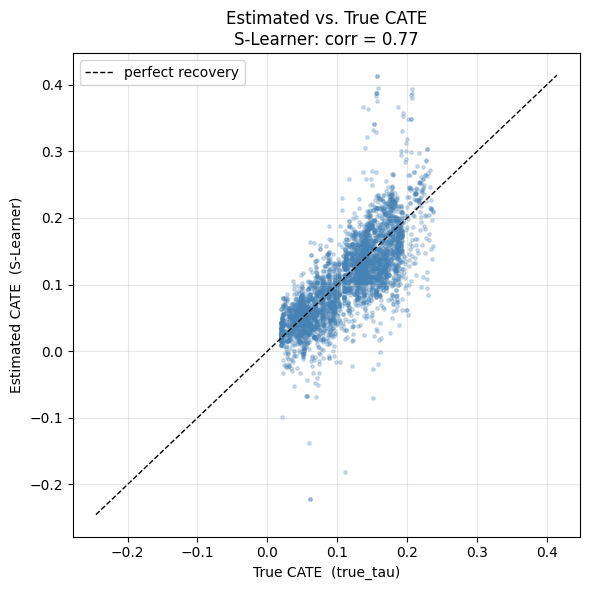

In [9]:
# Figure 1 — true vs. estimated CATE for a representative learner.
# Choose the learner that best recovers the true CATE (data-dependent, not hard-coded,
# so the headline figures show whichever method recovered the truth best here).
representative = recovery.sort_values('Corr(est, true)', ascending=False).iloc[0]['Method']
print(f"Representative learner (highest CATE recovery): {representative}")
cate_rep = results[representative]['cate']
corr = np.corrcoef(cate_rep, tau_eval)[0, 1]

fig, ax = plt.subplots(figsize=(6, 6))
samp = rng.choice(len(tau_eval), size=min(4000, len(tau_eval)), replace=False)
ax.scatter(tau_eval[samp], cate_rep[samp], s=6, alpha=0.25, color='steelblue')
lo = min(tau_eval.min(), cate_rep.min())
hi = max(tau_eval.max(), cate_rep.max())
ax.plot([lo, hi], [lo, hi], color='black', linestyle='--', linewidth=1, label='perfect recovery')
ax.set_xlabel('True CATE  (true_tau)')
ax.set_ylabel(f'Estimated CATE  ({representative})')
ax.set_title(f'Estimated vs. True CATE\n{representative}: corr = {corr:.2f}')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
savefig(fig, 'true_vs_estimated_cate.png')
plt.show()

A tight cloud around the dashed 45° line means the learner recovered both the
ranking and the magnitude. Vertical spread at a given true value is estimation
noise — expected with binary outcomes.

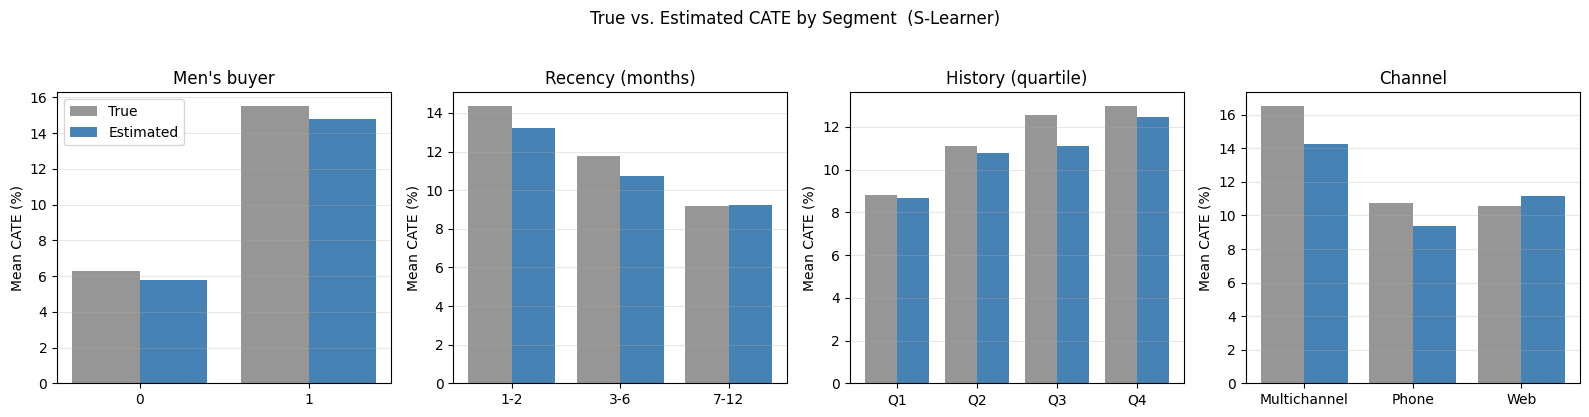

In [10]:
# Figure 2 — mean true vs. mean estimated CATE across business-readable segments.
eval_df = pd.DataFrame({
    'true_tau': tau_eval,
    'est_cate': results[representative]['cate'],
    'mens': X_eval[:, list(X.columns).index('mens')].astype(int),
})
# Recover readable segment columns aligned to the eval split.
_, eval_idx = train_test_split(np.arange(len(df)), test_size=0.30,
                               stratify=T, random_state=RANDOM_STATE)
eval_meta = df.iloc[eval_idx]
eval_df['recency_bucket'] = pd.cut(eval_meta['recency'].to_numpy(),
                                   [0, 2, 6, 12], labels=['1-2', '3-6', '7-12'])
eval_df['history_bucket'] = pd.qcut(eval_meta['history'].to_numpy(), 4,
                                    labels=['Q1', 'Q2', 'Q3', 'Q4'])
eval_df['channel'] = eval_meta['channel'].to_numpy()

dims = [
    ('mens', 'Men\'s buyer'),
    ('recency_bucket', 'Recency (months)'),
    ('history_bucket', 'History (quartile)'),
    ('channel', 'Channel'),
]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (col, title) in zip(axes, dims):
    g = eval_df.groupby(col, observed=True)[['true_tau', 'est_cate']].mean()
    xpos = np.arange(len(g))
    ax.bar(xpos - 0.2, g['true_tau'] * 100, width=0.4, label='True', color='#969696')
    ax.bar(xpos + 0.2, g['est_cate'] * 100, width=0.4, label='Estimated', color='steelblue')
    ax.set_xticks(xpos)
    ax.set_xticklabels([str(i) for i in g.index], rotation=0)
    ax.set_title(title)
    ax.set_ylabel('Mean CATE (%)')
    ax.grid(alpha=0.3, axis='y')
axes[0].legend()
plt.suptitle(f'True vs. Estimated CATE by Segment  ({representative})', y=1.03)
plt.tight_layout()
savefig(fig, 'cate_by_segment.png')
plt.show()

The estimated bars track the true bars across every cut — higher for men's
buyers, recent customers, and multichannel shoppers — which is exactly the
heterogeneity we built into `true_tau`. This is the segment-level signal you
would actually act on.

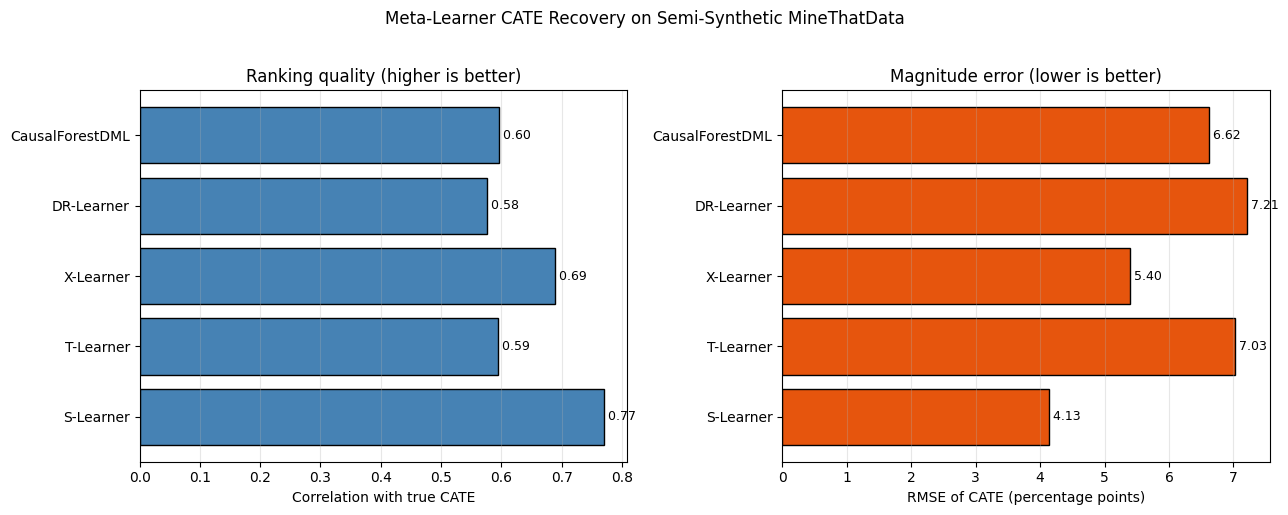

In [11]:
# Figure 3 — recovery quality across methods (correlation and RMSE).
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
names = list(results.keys())
corrs = [np.corrcoef(results[n]['cate'], tau_eval)[0, 1] for n in names]
rmses = [np.sqrt(((results[n]['cate'] - tau_eval) ** 2).mean()) * 100 for n in names]

axes[0].barh(names, corrs, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Correlation with true CATE')
axes[0].set_title('Ranking quality (higher is better)')
axes[0].grid(alpha=0.3, axis='x')
for i, v in enumerate(corrs):
    axes[0].text(v, i, f' {v:.2f}', va='center', fontsize=9)

axes[1].barh(names, rmses, color='#e6550d', edgecolor='black')
axes[1].set_xlabel('RMSE of CATE (percentage points)')
axes[1].set_title('Magnitude error (lower is better)')
axes[1].grid(alpha=0.3, axis='x')
for i, v in enumerate(rmses):
    axes[1].text(v, i, f' {v:.2f}', va='center', fontsize=9)

plt.suptitle('Meta-Learner CATE Recovery on Semi-Synthetic MineThatData', y=1.02)
plt.tight_layout()
savefig(fig, 'method_comparison_mtd.png')
plt.show()

## 7. What to Check Before Trusting CATE

This example is forgiving by design: the treatment is randomized, overlap is
perfect, and we know the truth. Real projects are not. Before acting on CATE
estimates:

- **The individual treatment effect is never observed in real data.** We only
  ever recovered `true_tau` here because we simulated it.
- **CATE is a model estimate, not a measurement.** Read it at the **group or
  segment level** (a decile, a channel), not as a literal number for one
  customer.
- **Sanity-check the mean.** If the average estimated CATE is wildly different
  from a simple difference-in-means on an experiment, something is wrong.
- **Check stability across learners.** If S/T/X and the Causal Forest disagree
  on the *ranking*, trust none of them yet.
- **Watch overlap.** Where treated and control customers do not coexist, CATE
  is an extrapolation, not an estimate.

### A quick sanity check: shuffle the treatment

If we randomly shuffle the treatment labels, any real relationship between
covariates and treatment effect is destroyed. A trustworthy pipeline should
then recover **no** heterogeneity — its CATE estimates should no longer
correlate with the true effect.

In [12]:
T_shuffled = rng.permutation(T_train)
placebo = TLearner(models=[LGBMRegressor(**lgbm_reg_params),
                           LGBMRegressor(**lgbm_reg_params)])
placebo.fit(y_train_f, T_shuffled, X=X_train)
placebo_cate = placebo.effect(X_eval).flatten()

print(f"Real T-Learner   corr with true CATE: "
      f"{np.corrcoef(results['T-Learner']['cate'], tau_eval)[0, 1]:.3f}")
print(f"Shuffled T-Learner corr with true CATE: "
      f"{np.corrcoef(placebo_cate, tau_eval)[0, 1]:.3f}  (should be ~0)")

Real T-Learner   corr with true CATE: 0.594
Shuffled T-Learner corr with true CATE: -0.077  (should be ~0)


## Summary

- On randomized data with known truth, **all five learners recover the average
  effect and the broad segment pattern** we built into `true_tau`. Individual
  estimates are noisier — correlations with the truth sit in the 0.58–0.77 range
  because the outcome is binary.
- **Which learner ranks best is data-dependent.** Here the simple S-Learner and
  the X-Learner lead; the two-model and cross-fitting learners pay a variance
  cost on this clean, balanced sample. Reputation is no substitute for checking.
- The **correlation with the true CATE** is the metric to watch — a learner can
  be off on magnitude yet still rank customers correctly, which is all targeting
  needs.
- Trust CATE at the **segment level**, validate **mean** plausibility, and check
  **stability across learners** before acting.

We now have per-customer estimates of *where the effect is larger or smaller*.
**§3.6 turns these scores into targeting decisions** — ranking, deciles, the
uplift and Qini curves, and net value after treatment cost.